In [8]:
import pandas as pd

In [9]:
cahd =pd.read_csv('CAHD.csv')
mddw =pd.read_csv('MDDW.csv')
fbs =pd.read_csv('FBS.csv')

In [10]:
cahd.head()


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Release Code,Release,Unit,...,Y2021,Y2021F,Y2022,Y2022F,Y2023,Y2023F,Y2024,Y2024F,Y2025,Y2025F
0,3,'008,Albania,70040,Cost of a healthy diet (CoHD),6226,Value,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,...,3.49,E,4.17,E,4.88,E,4.99,E,5.16,E
1,3,'008,Albania,70041,Cost of a healthy diet (CoHD),6205,Value,7S2026,July 2026 (SOFI report),LCU/cap/d,...,182.48,E,203.92,E,223.17,E,229.06,E,235.21,E
2,3,'008,Albania,70070,Cost of starchy staples,6226,Value,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,...,0.47,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,'008,Albania,70071,Cost of starchy staples,6205,Value,7S2026,July 2026 (SOFI report),LCU/cap/d,...,24.81,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,'008,Albania,70080,Cost of animal source foods,6226,Value,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,...,1.13,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
cahd.isna().sum()

Area Code             0
Area Code (M49)       0
Area                  0
Item Code             0
Item                  0
Element Code          0
Element               0
Release Code          0
Release               0
Unit                  0
Y2017              2660
Y2017F             2580
Y2018              2660
Y2018F             2580
Y2019              2660
Y2019F             2580
Y2020              2660
Y2020F             2580
Y2021               230
Y2021F                0
Y2022              2660
Y2022F             2580
Y2023              2660
Y2023F             2580
Y2024              2664
Y2024F             2580
Y2025              2664
Y2025F             2580
dtype: int64

In [12]:
cahd_long = cahd.melt(
    id_vars=["Area", "Area Code", "Area Code (M49)", "Item", "Item Code", "Element", "Element Code", "Unit"],
    value_vars=[col for col in cahd.columns if col.startswith("Y20") and not col.endswith("F")],
    var_name="Year",
    value_name="Value"
)

# Clean the name of the year (Y2020 → 2020)
cahd_long["Year"] = cahd_long["Year"].str.replace("Y", "").astype(int)

cahd_long.head()


,Area,Area Code,Area Code (M49),Item,Item Code,Element,Element Code,Unit,Year,Value
0,Albania,3,'008,Cost of a healthy diet (CoHD),70040,Value,6226,Int$ (PPP) per person per day,2017,3.04
1,Albania,3,'008,Cost of a healthy diet (CoHD),70041,Value,6205,LCU/cap/d,2017,160.41
2,Albania,3,'008,Cost of starchy staples,70070,Value,6226,Int$ (PPP) per person per day,2017,NaN
3,Albania,3,'008,Cost of starchy staples,70071,Value,6205,LCU/cap/d,2017,NaN
4,Albania,3,'008,Cost of animal source foods,70080,Value,6226,Int$ (PPP) per person per day,2017,NaN


In [13]:
mddw.head()

,Survey Code,Survey,Food Group Code,Food Group,Indicator Code,Indicator,Geographic Level Code,Geographic Level,Element Code,Element,Unit,Value,Flag
0,076_2014,Brazil - 2014,FGW0,MDD-W Food groups,6211,Percentage of women achieving MDD-W,10000,National,6121,Value,%,54.8,E
1,076_2014,Brazil - 2014,FGW0,MDD-W Food groups,6211,Percentage of women achieving MDD-W,10002,Rural,6121,Value,%,70.1,E
2,076_2014,Brazil - 2014,FGW0,MDD-W Food groups,6211,Percentage of women achieving MDD-W,10001,Urban,6121,Value,%,54.4,E
3,076_2014,Brazil - 2014,FGW1,"Grains, white roots and tubers, and plantains",6212,Percentage of women consuming each food group,10000,National,6121,Value,%,98.9,E
4,076_2014,Brazil - 2014,FGW1,"Grains, white roots and tubers, and plantains",6212,Percentage of women consuming each food group,10002,Rural,6121,Value,%,99.6,E


In [14]:
print(mddw.columns.tolist())

['Survey Code', 'Survey', 'Food Group Code', 'Food Group', 'Indicator Code', 'Indicator', 'Geographic Level Code', 'Geographic Level', 'Element Code', 'Element', 'Unit', 'Value', 'Flag']


In [15]:
fbs.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Y2010,...,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N
0,2,'004,Afghanistan,2501,'S2501,Population,511,Total Population - Both sexes,1000 No,28284.09,...,NaN,40000.41,X,NaN,40578.84,X,NaN,41454.76,X,NaN
1,2,'004,Afghanistan,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,2200.21,...,NaN,2244.73,E,NaN,2268.63,E,NaN,2314.63,E,NaN
2,2,'004,Afghanistan,2901,'S2901,Grand Total,661,Food supply (kcal),million Kcal,22714261.33,...,NaN,32773345.26,E,NaN,33601287.96,E,NaN,35022662.41,E,NaN
3,2,'004,Afghanistan,2901,'S2901,Grand Total,674,Protein supply quantity (g/capita/day),g/cap/d,65.54,...,NaN,61.36,E,NaN,61.55,E,NaN,62.58,E,NaN
4,2,'004,Afghanistan,2901,'S2901,Grand Total,671,Protein supply quantity (t),t,676666.08,...,NaN,895904.37,E,NaN,911681.15,E,NaN,946916.80,E,NaN


In [16]:
id_vars = [
    "Area Code", "Area Code (M49)", "Area",
    "Item Code", "Item Code (FBS)", "Item",
    "Element Code", "Element", "Unit"
]

value_vars = [col for col in fbs.columns if col.startswith("Y") and col[-1].isdigit()]

fbs_long = fbs.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="Year",
    value_name="Value"
)

# limpar o nome da coluna Year
fbs_long["Year"] = fbs_long["Year"].str.replace("Y", "").astype(int)


In [17]:
fbs_long.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Year,Value
0,2,'004,Afghanistan,2501,'S2501,Population,511,Total Population - Both sexes,1000 No,2010,28284.09
1,2,'004,Afghanistan,2901,'S2901,Grand Total,664,Food supply (kcal/capita/day),kcal/cap/d,2010,2200.21
2,2,'004,Afghanistan,2901,'S2901,Grand Total,661,Food supply (kcal),million Kcal,2010,22714261.33
3,2,'004,Afghanistan,2901,'S2901,Grand Total,674,Protein supply quantity (g/capita/day),g/cap/d,2010,65.54
4,2,'004,Afghanistan,2901,'S2901,Grand Total,671,Protein supply quantity (t),t,2010,676666.08


In [18]:
[col for col in fbs_long.columns if col != col.strip()]


[]

In [19]:
[col for col in cahd_long.columns if col != col.strip()]


[]

In [20]:
[col for col in mddw.columns if col != col.strip()]


[]

In [21]:
mddw[mddw.duplicated()]


,Survey Code,Survey,Food Group Code,Food Group,Indicator Code,Indicator,Geographic Level Code,Geographic Level,Element Code,Element,Unit,Value,Flag


In [22]:
fbs_long[fbs_long.duplicated()]


,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Year,Value


In [23]:
cahd_long[cahd_long.duplicated()]


,Area,Area Code,Area Code (M49),Item,Item Code,Element,Element Code,Unit,Year,Value


In [24]:
cahd_long.isna().sum().sort_values(ascending=False)


Value              21518
Area                   0
Area Code              0
Area Code (M49)        0
Item                   0
Item Code              0
Element                0
Element Code           0
Unit                   0
Year                   0
dtype: int64

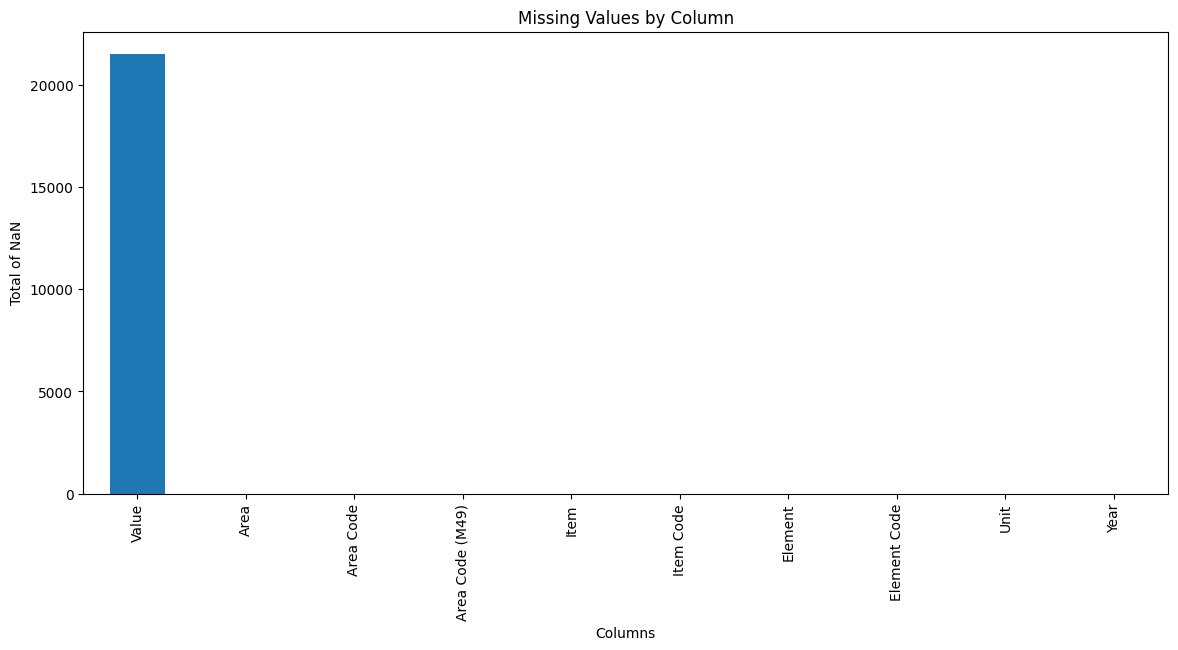

In [25]:
import matplotlib.pyplot as plt

cahd_long.isna().sum().sort_values(ascending=False).plot(kind="bar", figsize=(14,6))
plt.title("Missing Values by Column")
plt.ylabel("Total of NaN")
plt.xlabel("Columns")
plt.show()


In [26]:
fbs_long.isna().sum().sort_values(ascending=False)


Value              410883
Area Code               0
Area Code (M49)         0
Area                    0
Item Code               0
Item Code (FBS)         0
Item                    0
Element Code            0
Element                 0
Unit                    0
Year                    0
dtype: int64

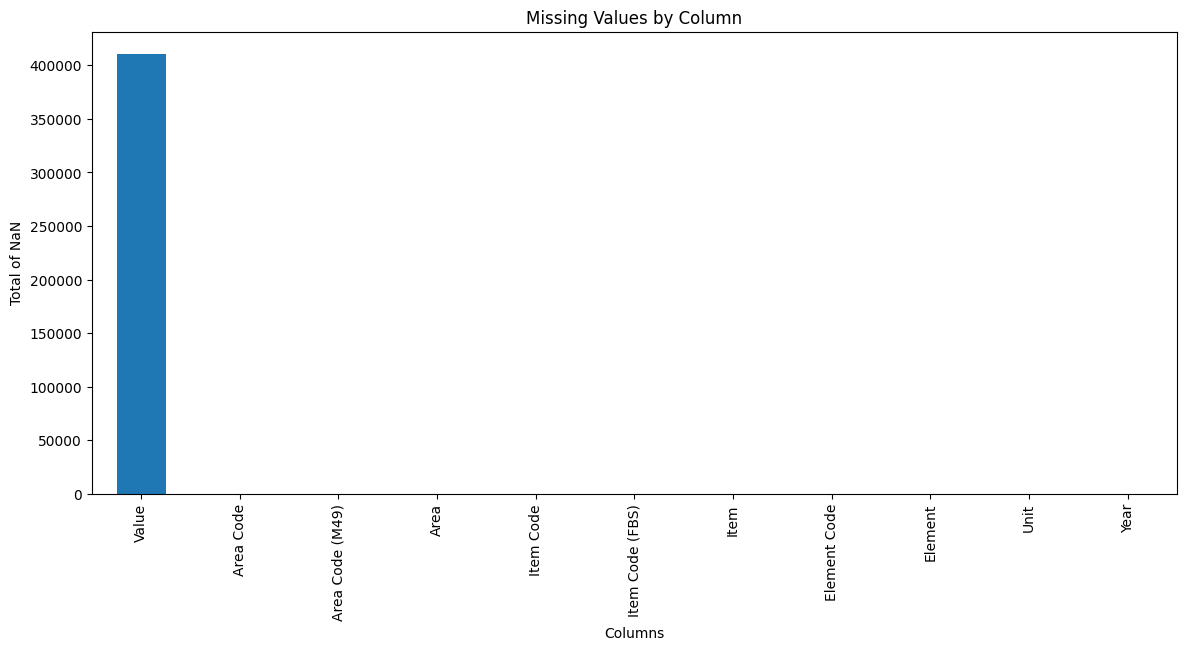

In [27]:
import matplotlib.pyplot as plt

fbs_long.isna().sum().sort_values(ascending=False).plot(kind="bar", figsize=(14,6))
plt.title("Missing Values by Column")
plt.ylabel("Total of NaN")
plt.xlabel("Columns")
plt.show()

In [28]:
mddw.isna().sum().sort_values(ascending=False)


Survey Code              0
Survey                   0
Food Group Code          0
Food Group               0
Indicator Code           0
Indicator                0
Geographic Level Code    0
Geographic Level         0
Element Code             0
Element                  0
Unit                     0
Value                    0
Flag                     0
dtype: int64

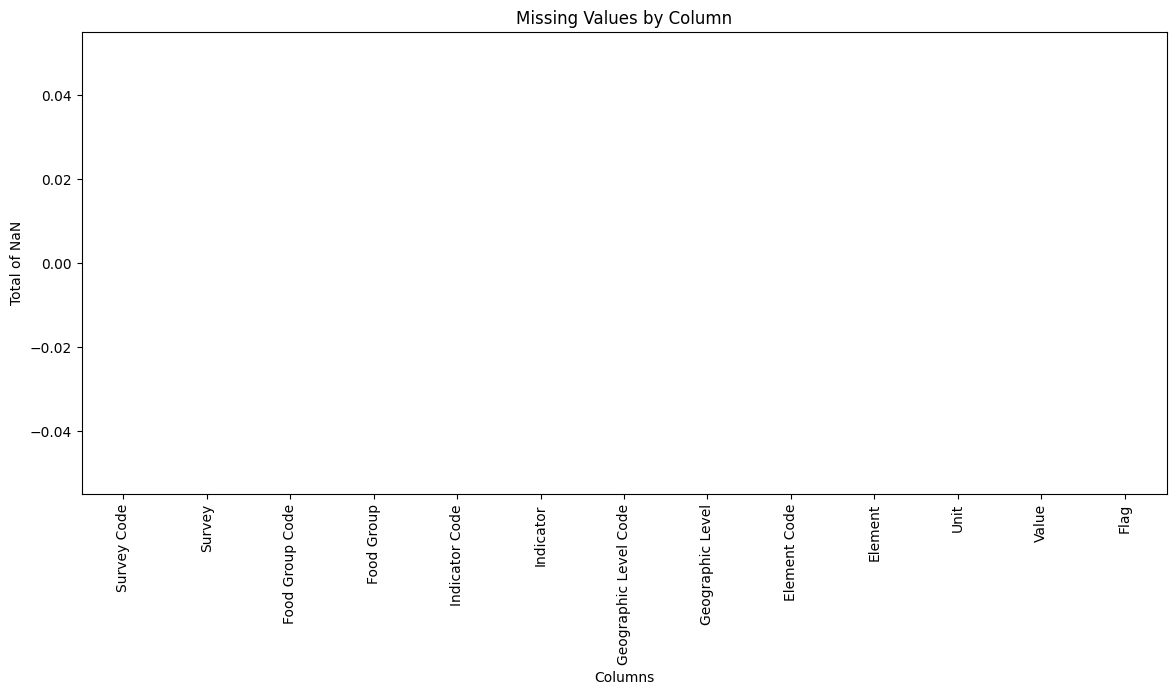

In [29]:
import matplotlib.pyplot as plt

mddw.isna().sum().sort_values(ascending=False).plot(kind="bar", figsize=(14,6))
plt.title("Missing Values by Column")
plt.ylabel("Total of NaN")
plt.xlabel("Columns")
plt.show()

In [30]:
# I want to merge the three dataset but first
# I change the nome of columns dont make confusion 

In [31]:
cahd_long = cahd_long.rename(columns={"Value": "Cost_or_Affordability"})
mddw = mddw.rename(columns={"Value": "Women_Diet_Diversity"})


In [32]:
mddw["Area"] = mddw["Survey"].str.split(" - ").str[0]
mddw["Year"] = mddw["Survey"].str.extract(r"(\d{4})").astype(int)


In [33]:
fbs_long["Year"] = fbs_long["Year"].astype(str).str.replace("Y", "").astype(int)


In [34]:
fbs_long["Year"].head()


0    2010
1    2010
2    2010
3    2010
4    2010
Name: Year, dtype: int32

In [35]:
value_vars = [col for col in fbs.columns if col.startswith("Y") and col[-1].isdigit()]

fbs_long = fbs.melt(
    id_vars=["Area Code", "Area Code (M49)", "Area",
             "Item Code", "Item Code (FBS)", "Item",
             "Element Code", "Element", "Unit"],
    value_vars=value_vars,
    var_name="Year",
    value_name="Value_cahd"
)

fbs_long["Year"] = fbs_long["Year"].astype(str).str.replace("Y", "").astype(int)


In [36]:
mddw["Area"] = mddw["Survey"].str.split(" - ").str[0]
mddw["Year"] = mddw["Survey"].str.extract(r"(\d{4})").astype(int)

mddw = mddw.rename(columns={"Value": "Value_mddw"})


In [37]:
merge_1 = fbs_long.merge(
    mddw,
    on=["Area", "Year"],
    how="outer"
)


In [38]:
merge_1.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code_x,Element_x,Unit_x,Year,...,Food Group,Indicator Code,Indicator,Geographic Level Code,Geographic Level,Element Code_y,Element_y,Unit_y,Women_Diet_Diversity,Flag
0,2.0,'004,Afghanistan,2501.0,'S2501,Population,511.0,Total Population - Both sexes,1000 No,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,664.0,Food supply (kcal/capita/day),kcal/cap/d,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,661.0,Food supply (kcal),million Kcal,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,674.0,Protein supply quantity (g/capita/day),g/cap/d,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,671.0,Protein supply quantity (t),t,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df_final = merge_1.merge(
    cahd_long,
    on=["Area", "Year"],
    how="outer"
)


In [40]:
df_final.head()

,Area Code_x,Area Code (M49)_x,Area,Item Code_x,Item Code (FBS),Item_x,Element Code_x,Element_x,Unit_x,Year,...,Women_Diet_Diversity,Flag,Area Code_y,Area Code (M49)_y,Item_y,Item Code_y,Element,Element Code,Unit,Cost_or_Affordability
0,2.0,'004,Afghanistan,2501.0,'S2501,Population,511.0,Total Population - Both sexes,1000 No,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,664.0,Food supply (kcal/capita/day),kcal/cap/d,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,661.0,Food supply (kcal),million Kcal,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,674.0,Protein supply quantity (g/capita/day),g/cap/d,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,'004,Afghanistan,2901.0,'S2901,Grand Total,671.0,Protein supply quantity (t),t,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df_final.columns

Index(['Area Code_x', 'Area Code (M49)_x', 'Area', 'Item Code_x',
       'Item Code (FBS)', 'Item_x', 'Element Code_x', 'Element_x', 'Unit_x',
       'Year', 'Value_cahd', 'Survey Code', 'Survey', 'Food Group Code',
       'Food Group', 'Indicator Code', 'Indicator', 'Geographic Level Code',
       'Geographic Level', 'Element Code_y', 'Element_y', 'Unit_y',
       'Women_Diet_Diversity', 'Flag', 'Area Code_y', 'Area Code (M49)_y',
       'Item_y', 'Item Code_y', 'Element', 'Element Code', 'Unit',
       'Cost_or_Affordability'],
      dtype='object')

In [42]:
df_final.shape

(65795297, 32)

In [43]:
df_final.isna().sum()


Area Code_x                 10864
Area Code (M49)_x           10864
Area                            0
Item Code_x                 10864
Item Code (FBS)             10864
Item_x                      10864
Element Code_x              10864
Element_x                   10864
Unit_x                      10864
Year                            0
Value_cahd                3992798
Survey Code              39553077
Survey                   39553077
Food Group Code          39553077
Food Group               39553077
Indicator Code           39553077
Indicator                39553077
Geographic Level Code    39553077
Geographic Level         39553077
Element Code_y           39553077
Element_y                39553077
Unit_y                   39553077
Women_Diet_Diversity     39553077
Flag                     39553077
Area Code_y               3244561
Area Code (M49)_y         3244561
Item_y                    3244561
Item Code_y               3244561
Element                   3244561
Element Code  

In [ ]:
df_final = df_final.drop_duplicates()



In [ ]:
df_final.shape

In [ ]:
df_final = df_final.dropna()

In [ ]:
df_final.shape

In [ ]:
#Countries where a healthy diet is more expensive
df_final.groupby("Area")["Cost_or_Affordability"].mean().sort_values(ascending=False)


In [ ]:
#Countries where women have less dietary diversity

df_final.groupby("Area")["Women_Diet_Diversity"].mean().sort_values()


In [ ]:
#Relationship between diet cost and women's diversity
df_final[["Cost_or_Affordability", "Women_Diet_Diversity"]].corr()
